In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
atulyakumar98_pothole_detection_dataset_path = kagglehub.dataset_download('atulyakumar98/pothole-detection-dataset')

print('Data source import complete.')


100%|██████████| 194M/194M [00:01<00:00, 121MB/s]

Extracting files...


Data source import complete.


In [3]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

from glob import glob


In [4]:
# Keras CNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

# Image handling libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd

# Sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Data visualization
import matplotlib.pyplot as plt
from matplotlib import style

# Collect image paths
import os

imagepaths = []
for dirname, _, filenames in os.walk(atulyakumar98_pothole_detection_dataset_path):
    for filename in filenames:
        path = os.path.join(dirname, filename)
        imagepaths.append(path)

print(f'Total images found: {len(imagepaths)}')



Total images found: 681


In [5]:
import cv2
import numpy as np

IMG_SIZE = 128
X, y = [], []

for image in imagepaths:
    try:
        img = cv2.imread(image, cv2.IMREAD_COLOR)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(np.array(img))

        # ✅ Robust label extraction — works for any platform
        if 'normal' in image.lower():
            y.append('NORMAL')
        elif 'pothole' in image.lower():
            y.append('POTHOLES')
        else:
            # Skip if the path doesn't match expected pattern
            continue
    except Exception as e:
        print(f"Skipping {image} due to error: {e}")
        continue

print(f"✅ Loaded {len(X)} images")
print(f"🔹 Sample labels: {set(y)}")


✅ Loaded 681 images
🔹 Sample labels: {'NORMAL', 'POTHOLES'}


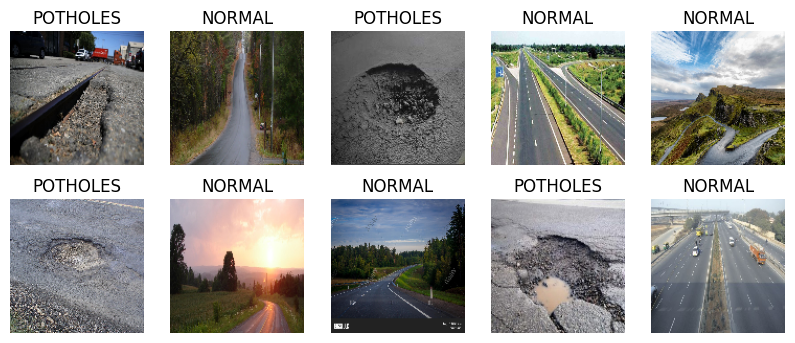

In [6]:
import random as rn
import matplotlib.pyplot as plt

# Example data setup
# X: images, y: labels
fig, ax = plt.subplots(2, 5, figsize=(10, 4))

for i in range(2):
    for j in range(5):
        l = rn.randrange(len(y))
        ax[i, j].imshow(X[l][:, :, ::-1])
        ax[i, j].set_title(y[l])
        ax[i, j].axis('off')

plt.show()


In [7]:
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

le=LabelEncoder()
Y=le.fit_transform(y)
Y=to_categorical(Y,2)
print(Y)
X=np.array(X)
#X=X/255

x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.25,random_state=5)

[[0. 1.]
 [0. 1.]
 [0. 1.]
 ...
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [8]:
# Create a CNN Sequential Model
model = Sequential()

model.add(Conv2D(32, (5,5), activation = 'relu', input_shape=(128,128,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())

model.add(Dropout(0.4))

model.add(Dense(128, activation='relu'))

model.add(Dense(2, activation='softmax'))

In [9]:
#Model configuration for training purpose
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [10]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 124, 124, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 455,874 (1.74 MB)

 Trainable params: 455,874 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

None


In [11]:
history = model.fit(
    x_train, y_train,
    epochs=30, batch_size=12, verbose=2,
    validation_data=(x_test, y_test)
)


Epoch 1/30
43/43 - 23s - 544ms/step - accuracy: 0.6275 - loss: 1.9571 - val_accuracy: 0.6433 - val_loss: 0.6568
Epoch 2/30
43/43 - 21s - 495ms/step - accuracy: 0.6863 - loss: 0.5923 - val_accuracy: 0.5673 - val_loss: 1.1322
Epoch 3/30
43/43 - 21s - 485ms/step - accuracy: 0.6118 - loss: 0.6890 - val_accuracy: 0.6023 - val_loss: 1.0999
Epoch 4/30
43/43 - 20s - 474ms/step - accuracy: 0.7255 - loss: 0.5337 - val_accuracy: 0.7661 - val_loss: 0.5353
Epoch 5/30
43/43 - 22s - 501ms/step - accuracy: 0.7588 - loss: 0.4916 - val_accuracy: 0.7895 - val_loss: 0.4873
Epoch 6/30
43/43 - 20s - 454ms/step - accuracy: 0.8333 - loss: 0.3583 - val_accuracy: 0.7018 - val_loss: 0.6227
Epoch 7/30
43/43 - 21s - 484ms/step - accuracy: 0.8275 - loss: 0.3905 - val_accuracy: 0.8538 - val_loss: 0.4227
Epoch 8/30
43/43 - 41s - 945ms/step - accuracy: 0.9098 - loss: 0.2750 - val_accuracy: 0.8480 - val_loss: 0.3546
Epoch 9/30
43/43 - 21s - 477ms/step - accuracy: 0.8235 - loss: 0.4083 - val_accuracy: 0.7544 - val_loss:

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 278ms/step
📊 Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.93      0.81      0.87        96
    POTHOLES       0.79      0.92      0.85        75

    accuracy                           0.86       171
   macro avg       0.86      0.87      0.86       171
weighted avg       0.87      0.86      0.86       171


✅ Accuracy:  85.96%
🎯 Precision: 79.31%
🔁 Recall:    92.00%
📈 F1-score:  85.19%


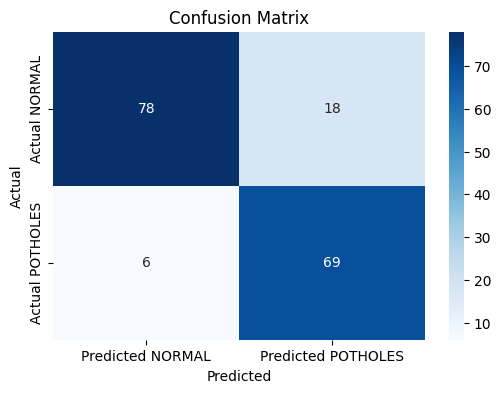

In [12]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Predict classes
y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

# --- Classification Report ---
print("📊 Classification Report:")
print(classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=["NORMAL", "POTHOLES"],
    zero_division=0
))

# --- Basic Metrics (handle single-class gracefully) ---
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, labels=[0,1], average='binary', zero_division=0)
rec = recall_score(y_true, y_pred, labels=[0,1], average='binary', zero_division=0)
f1 = f1_score(y_true, y_pred, labels=[0,1], average='binary', zero_division=0)

print(f"\n✅ Accuracy:  {acc*100:.2f}%")
print(f"🎯 Precision: {prec*100:.2f}%")
print(f"🔁 Recall:    {rec*100:.2f}%")
print(f"📈 F1-score:  {f1*100:.2f}%")

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
df_cm = pd.DataFrame(
    cm,
    columns=["Predicted NORMAL", "Predicted POTHOLES"],
    index=["Actual NORMAL", "Actual POTHOLES"]
)

plt.figure(figsize=(6,4))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


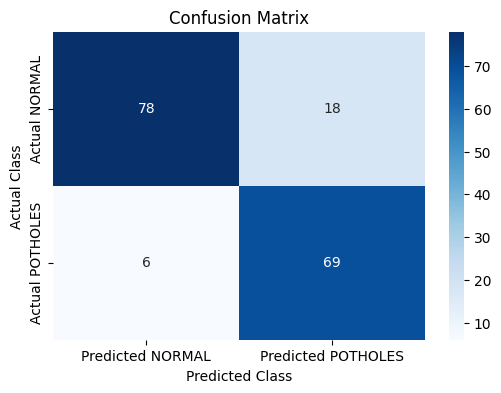

In [13]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
df_cm = pd.DataFrame(cm,
                     columns=["Predicted NORMAL", "Predicted POTHOLES"],
                     index=["Actual NORMAL", "Actual POTHOLES"])

plt.figure(figsize=(6,4))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.show()


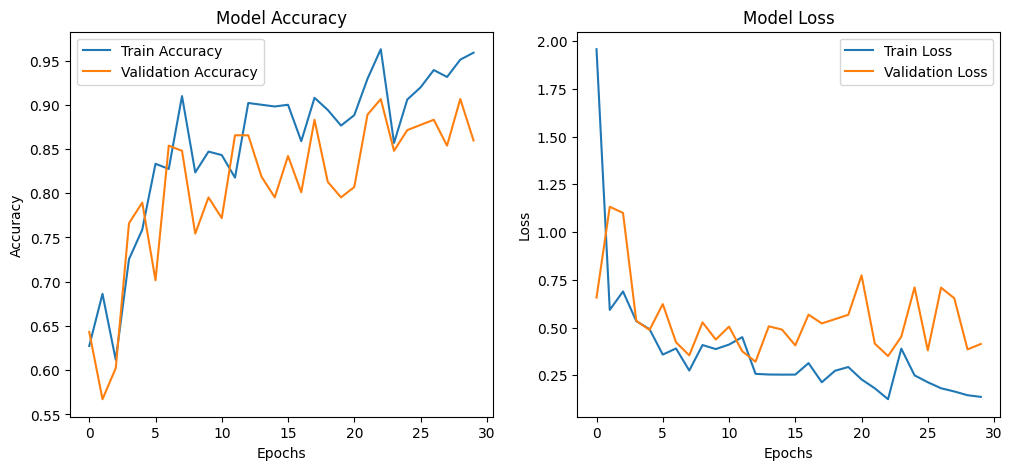

In [14]:
# --- Plot training performance ---
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [15]:

loss, accuracy = model.evaluate(x_test, y_test)

print('Test accuracy: {:2.2f}%'.format(accuracy*100))

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 262ms/step - accuracy: 0.8507 - loss: 0.4397
Test accuracy: 85.96%


In [16]:
model.save("model.h5")

In [17]:
# Making predictions on test data
prediction = model.predict(x_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 264ms/step


In [18]:
#Transform predictions into 1D array
y_pred = np.argmax(prediction, axis=1)

In [19]:
y_test1=y_test.astype(int)
y_test2=[]
for i in y_test1:
    a=1
    #print(i[0],i[1])
    if(i[0]==1 and i[1]==0):
        a=0
    y_test2.append(a)


In [20]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test2, y_pred, labels=[0, 1])  # include both classes explicitly

df_cm = pd.DataFrame(cm,
                     columns=["Predicted NORMAL", "Predicted POTHOLES"],
                     index=["Actual NORMAL", "Actual POTHOLES"])
print(df_cm)


                 Predicted NORMAL  Predicted POTHOLES
Actual NORMAL                  78                  18
Actual POTHOLES                 6                  69


# **VGG16 Transfer Learning**

In [21]:
IMG_SIZE=128

# training config:
epochs = 5
batch_size = 32

X=[]
y=[]
for image in imagepaths:
    try:
        img = cv2.imread(image,cv2.IMREAD_COLOR)
        img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))

        X.append(np.array(img))
        if(image.startswith('/kaggle/input/pothole-detection-dataset/normal/')):
            y.append('NORMAL')
        else:
            y.append('POTHOLES')
    except:
        pass

In [22]:
IMG_SIZE=128

# training config:
epochs = 5
batch_size = 32

filename=[]
y=[]
for image in imagepaths:
    try:
        #filename.append(image[image.rfind('/')+1:])
        filename.append(image)
        if(image.startswith('/kaggle/input/pothole-detection-dataset/normal/')):
            y.append('NORMAL')
        else:
            y.append('POTHOLES')
    except:
        pass

In [23]:
img_df = pd.DataFrame(
    {'filename': filename,
     'y': y
    })

img_df=img_df.sample(frac=1)

In [24]:
tr_img=img_df[:450]
valid_img=img_df[450:]

In [25]:
IMAGE_SIZE = [128, 128]
vgg = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [26]:
# don't train existing weights
for layer in vgg.layers:
  layer.trainable = False

In [27]:
folders = glob('/kaggle/input/pothole-detection-dataset' + '/*')

In [28]:
# our layers - you can add more if you want
x = Flatten()(vgg.output)
# x = Dense(1000, activation='relu')(x)
prediction = Dense(len(folders), activation='softmax')(x)

In [29]:
# create a model object
model = Model(inputs=vgg.input, outputs=prediction)

In [30]:
# view the structure of the model
model.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 0)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [31]:
# tell the model what cost and optimization method to use
model.compile(
  loss='categorical_crossentropy',
  optimizer='rmsprop',
  metrics=['accuracy'])

In [32]:
# create an instance of ImageDataGenerator
gen = ImageDataGenerator(
  rotation_range=20,
  width_shift_range=0.1,
  height_shift_range=0.1,
  shear_range=0.1,
  zoom_range=0.2,
  horizontal_flip=True,
  vertical_flip=True,
  preprocessing_function=preprocess_input
)

In [33]:
test_gen = gen.flow_from_dataframe(
        dataframe=img_df,
        #directory='/kaggle/input/pothole-detection-dataset',
        x_col="filename",
        y_col="y",
        target_size=IMAGE_SIZE)
print(test_gen.class_indices)

Found 681 validated image filenames belonging to 1 classes.
{'POTHOLES': 0}


In [34]:
labels = [None] * len(test_gen.class_indices)
for k, v in test_gen.class_indices.items():
  labels[v] = k

min: -123.68 max: 151.061


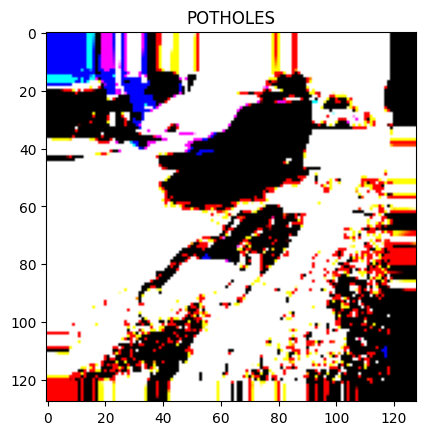

In [35]:
try:
    for x, y in test_gen:
      print("min:", x[0].min(), "max:", x[0].max())
      plt.title(labels[np.argmax(y[0])])
      plt.imshow(x[0])
      plt.show()
      break
except:
    pass

In [36]:
train_path = '/kaggle/input/pothole-detection-dataset'
# create generators
train_generator = gen.flow_from_dataframe(
        dataframe=tr_img,
        #directory='/kaggle/input/pothole-detection-dataset',
        x_col="filename",
        y_col="y",
        target_size=IMAGE_SIZE,
        shuffle=True,
      batch_size=batch_size)

valid_generator = gen.flow_from_dataframe(
        dataframe=valid_img,
        directory='/kaggle/input/pothole-detection-dataset',
        x_col="filename",
        y_col="y",
        target_size=IMAGE_SIZE,
        shuffle=True,
      batch_size=batch_size)

Found 450 validated image filenames belonging to 1 classes.
Found 231 validated image filenames belonging to 1 classes.


In [37]:
train_img_path = '/kaggle/input/pothole-detection-dataset' + '/*/*.j*'
# fit the model
try:
    r = model.fit_generator(
          train_generator,
          validation_data=valid_generator,
          epochs=epochs,
          steps_per_epoch=len(image_files) // batch_size,
          validation_steps=len(valid_image_files) // batch_size)
except:
    pass

In [38]:
# Evaluate on validation set
val_loss, val_acc = model.evaluate(valid_generator)
print(f"Validation Accuracy: {val_acc*100:.2f}%")

# Plot training history
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(r.history['accuracy'], label='Train Acc')
plt.plot(r.history['val_accuracy'], label='Val Acc')
plt.title('VGG16 Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(r.history['loss'], label='Train Loss')
plt.plot(r.history['val_loss'], label='Val Loss')
plt.title('VGG16 Loss')
plt.legend()
plt.show()


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 1), output.shape=(None, 0)

In [ ]:
model.save("model2.h5")